# Social network analysis 2: Create a network from text data and analyze it

In this workshop, we will use networkx to create a network from text data, open it in Gephi, and then use networkx to analyze its structure.


### Part 1. Extract interactions from textual data

In this exercise, we will go from data in a dataframe to creating a network that we can analyze, and that we can open with Gephi.

In your own project, you are unlikely to come across ready-to-process data in a format that you can open with networkx or Gephi. Instead, you need to create network from your own data.

In this case, we will look at a classic dataset: the Enron emails. The Enron email dataset is a large collection of email data from mostly senior management of the Enron Corporation. It was made public by the Federal Energy Regulatory Commission during its investigation after Enron's collapse in 2001. The dataset contains roughly half a million emails organized into folders. It's one of the largest datasets of real-world emails available for public study and has been widely used for research in various fields like social network analysis, natural language processing, and machine learning.

The Enron dataset is particularly notable for its insights into corporate communications and behaviors, and it has played a significant role in advancing the study of information processing and management. Due to its real-world nature, including the variety of topics and the informal style of communication, the dataset presents unique challenges and opportunities for data analysis and has become a benchmark in the study of electronic communications.

We will here use the dataset to create a social network of emails between individuals, and we will analyze the structure of this network.

The Enron case led to the conviction of two managers: Kenneth Lay (kenneth.lay@enron.com) and Jeffrey Skilling (jeffreyskilling@yahoo.com). We will examine the centrality of these nodes in the network, and identify the community to which they belong. 

To make the analysis more feasible, we will focus on emails in 2001 - the year when the company went under!

In [14]:
import pandas as pd
df = pd.read_csv('enron2001.csv.gz')

In [2]:
df.head()

,message
0,Message-ID: <18782981.1075855378110.JavaMail.e...
1,Message-ID: <15464986.1075855378456.JavaMail.e...
2,Message-ID: <7391389.1075855378477.JavaMail.ev...
3,Message-ID: <8572706.1075855378498.JavaMail.ev...
4,Message-ID: <32300323.1075855378519.JavaMail.e...


As you can see, the email is just a long text message. We need to parse out the actual data and email addresses from the text using regexps.

In [4]:
display(df.message[0])

"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>\nDate: Mon, 14 May 2001 16:39:00 -0700 (PDT)\nFrom: phillip.allen@enron.com\nTo: tim.belden@enron.com\nSubject: \nMime-Version: 1.0\nContent-Type: text/plain; charset=us-ascii\nContent-Transfer-Encoding: 7bit\nX-From: Phillip K Allen\nX-To: Tim Belden <Tim Belden/Enron@EnronXGate>\nX-cc: \nX-bcc: \nX-Folder: \\Phillip_Allen_Jan2002_1\\Allen, Phillip K.\\'Sent Mail\nX-Origin: Allen-P\nX-FileName: pallen (Non-Privileged).pst\n\nHere is our forecast\n\n "

In [20]:
import re

#Example code for how to extract email subject and send date
def extract_subject(message):
    # Regular expression pattern to match the subject line
    pattern = r'^Subject: (.+)$'

    # Search for the pattern in the message, using multiline mode
    match = re.search(pattern, message, re.MULTILINE)

    # Return the subject if a match is found, else return None
    return match.group(1) if match else None

# Example: this function extracts a date from the email
def extract_date(message):
    match = re.search(r"Date: .*?, (\d+ \w+ \d{4})", message)
    return match.group(1) if match else None


# Extract and convert date
df['date'] = df['message'].apply(extract_date)
df['date'] = pd.to_datetime(df['date'], errors='coerce', format='%d %b %Y')

df['subject'] = df['message'].apply(extract_subject)
from_pattern = r"From: (\S+@\S+)"
to_pattern = r"To: ([\w\.,@]+)"
email_pattern = r'^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$'




In [21]:
#Solution
import re
def extract_from(text):
    from_pattern = r"From: (\S+@\S+)"
    from_email = re.search(from_pattern, text)
    if from_email:
        return from_email.group(1).strip(',').strip('.').strip()
    else:
        return None
def extract_to(text):
    to_pattern = r"To: ([\w\.,@]+)"
    to_email = re.search(to_pattern, text)
    if to_email:
        return to_email.group(1).strip(',').strip('.').strip()
    else:
        return None
df['from_email'] = df['message'].apply(extract_from)
df['to_email'] = df['message'].apply(extract_to)
#regular expression pattern for a valid email
email_pattern = r"^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$"
#filter df to make sure that the emails are valid
df = df[df['from_email'].str.match(email_pattern, na=False)]
df = df[df['to_email'].str.match(email_pattern, na=False)]
#resulting df should look like: message | data | from_email | to_email

# Group and count email pairs
email_edges = (df
    .groupby(['from_email', 'to_email'])  # Group by both columns
    .size()  # Count occurrences
    .reset_index(name='count')  # Convert to DataFrame with count column
    .sort_values('count', ascending=False)  # Sort by frequency
)
email_edges.head()

,from_email,to_email,count
34628,pete.davis@enron.com,pete.davis@enron.com,6463
45835,vince.kaminski@enron.com,vkaminski@aol.com,1645
18810,jeff.dasovich@enron.com,alan.comnes@enron.com,1052
12505,enron.announcements@enron.com,all.worldwide@enron.com,1029
12499,enron.announcements@enron.com,all.houston@enron.com,964


## Part 2: Create networkx graph from data 
In the next step, we're going to create a networkx graph from this network, and save to have a look at the graph in Gephi.

In [23]:
#Now it's time to create the network! 
import networkx as nx
G = nx.Graph()

# Use G.add_node(id, additional_data="data") to add nodes
# Use G.add_edge(from_id,to_id, weight=5) to add edges

# Two people were convicted in the Enron scandal: Kenneth Lay, and Jeffrey Skilling. 
# The nodes should have a property 'convicted'. If the email address is either 'kenneth.lay@enron.com' or 'jeffreyskilling@yahoo.com', convicted == True, otherwise False.

# [YOUR CODE HERE]

for email in list(set(email_edges['from_email']).union(email_edges['to_email'])):
    G.add_node(email, convicted=(email in ['kenneth.lay@enron.com', 'jeffreyskilling@yahoo.com']))

# Add edges with weights
for f, t, w in zip(email_edges['from_email'], email_edges['to_email'], email_edges['count']):
    G.add_edge(f, t, weight=w)
# Verify convicted nodes
assert G.nodes['kenneth.lay@enron.com']['convicted'] == True
assert G.nodes['jeffreyskilling@yahoo.com']['convicted'] == True



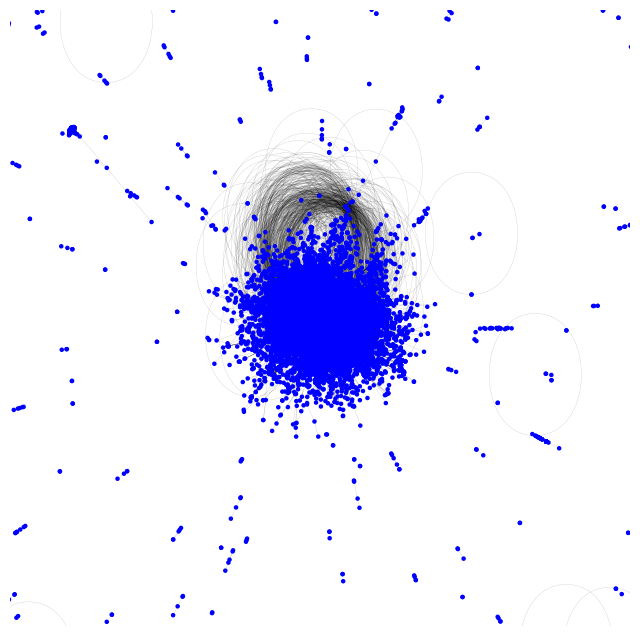

In [24]:
# # You can try to plot it - but you might find that the network is too big and that your python loads forever!

import networkx as nx
import matplotlib.pyplot as plt
def plot_network(G):
    # Create layout
    pos = nx.spring_layout(G, scale=2)
    # Configure plot size
    plt.figure(figsize=(8, 8))
    # Draw nodes (red for convicted, blue for others)
    node_color = ['red' if G.nodes[node].get('convicted', False) else 'blue' for node in G]
    nx.draw_networkx_nodes(G, pos, node_size=5, node_color=node_color)
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.5)
    # Set plot limits
    plt.xlim([-1, 1])
    plt.ylim([-1, 1])
    # Remove axis
    plt.axis('off')
    # Show plot
    plt.show()
# Generate visualization
plot_network(G)
# One way to plot is with nx.draw(G) - but not very pretty
# # The following code is more customizable 

# import matplotlib.pyplot as plt
# def plot_network(G):
#     # Use a layout that spreads out the nodes, like spring_layout
#     pos = nx.spring_layout(G, scale=2)
    
#     # Draw the network
#     plt.figure(figsize=(8, 8))  # Large figure size
    
#     #We plot the convicted individuals with red.
#     node_color = ['red' if G.nodes[node].get('convicted', False) else 'blue' for node in G]
#     nx.draw_networkx_nodes(G, pos, node_size=5, node_color=node_color)
#     nx.draw_networkx_edges(G, pos, width=0.1, alpha=0.5)
    
#     # Set plot limits to avoid cutting off nodes
#     plt.xlim([-1, 1])
#     plt.ylim([-1, 1])
    
#     # Turn off axis
#     plt.axis('off')
    
#     # Show plot
#     plt.show()
# plot_network(G)

#### Getting the giant component 
As you can see, the resulting network has a lot of small components that are not connected to the larger network. Often it makes sense to focus only on the giant component: that is, the biggest connected component in the network.

In [ ]:
# To get all the components of the graph, use nx.connected_components(G) 
# Remember that the giant component is the LARGEST component.

# Once you've identified it, you can use G.subgraph(component) to turn the nodes into a graph
# Put the result back in the variable G.

# [YOUR CODE HERE]

In [229]:
#The number of nodes in our new graph
len(G.nodes())

In [228]:
# Plot the giant component 
# plot_network(G)

## Part 3: Save the network, open with Gephi, and carry out Visual Network Analysis
We can now save the network as a file, so that we can open it with Gephi and analyze it.

There are several fileformats that we can save in, that are compatible with Gephi. GEXF and GraphML are two common formats. You can read more about the formats and their pros/cons on this website: https://networkx.org/documentation/stable/reference/readwrite/index.html 



In [25]:
nx.write_gexf(G,'enron_network.gexf')

In [ ]:
# If the network is too large to deal with on your laptop, you might want to filter out small nodes.

# Filter nodes with degree less than N
filtered_nodes = [node for node, degree in G.degree() if degree >= N]

# Create a new graph with the filtered nodes
filtered_graph = G.subgraph(filtered_nodes).copy()

Now open this file with Gephi and use it to create a better plot of the network!

Analyze the structure of the network and describe your overall take-aways.


## Part 4: Use networkx to analyze the convicted bankers
We're now going to use networkx to get some exact measures on the network, and to measure the centrality and influence of the two convicted bankers.

In [ ]:
pagerank = nx.pagerank(G)
betweenness = nx.betweenness_centrality(G)
degree_centrality = nx.degree_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

# [YOUR CODE HERE]

In [233]:
# Your output should look as follows:

# PageRank
# Kenneth lay is the number 2 most central.
# Jeffrey Skilling is the number 2478 most central

# Betweenness
# Kenneth lay is the number 6 most central.
# Jeffrey Skilling is the number 2158 most central

# Degree
# Kenneth lay is the number 2 most central.
# Jeffrey Skilling is the number 2221 most central

# Eigenvector
# Kenneth lay is the number 21 most central.
# Jeffrey Skilling is the number 1555 most central

### Find their communities
The second part is to use the Louvain community detection to identify which community the two belong to. 

We will then put the identified communities as a column in the original dataframe, allowing us to potentially carry out text analysis to identify what characterizes the communities.

In [240]:
# !pip3 install python-louvain

In [258]:
import community as community_louvain

# Detect communities using the Louvain method
partition = community_louvain.best_partition(G)

# Calculate the modularity
modularity = community_louvain.modularity(partition, G)

print("Modularity:", modularity)


In [262]:
# Identify which communities our two convicts are in!
# Use the partition to create a new column in the original df called "partition" that contains the partition of the individual associated to the email!

# The result should be a dataframe with the following structure:
# message | date | subject | from_email | to_email | partition

# [YOUR CODE HERE]

# Can you get a feeling for the communities by looking at the emails they are associated to? 
# Maybe do some word counting, topic modeling, maybe apply TF-IDF?
